# 🌱 PINN — Root-Zone Soil Moisture  *(Real-Time Dashboard)*
**Based on:** Chuphal et al. (2026) — *Scientific Data 13:560* | IIT Gandhinagar

> **Fix applied:** The dashboard now uses `%matplotlib widget` (ipympl) so the figure  
> lives in the DOM once and is updated **in-place** via `fig.canvas.draw_idle()`.  
> No `clear_output`, no `plt.show()` inside the loop — zero flicker, continuous refresh.

| | |
|---|---|
| **Target** | `SMAP_RZSM_m3m3` — root-zone soil moisture 0–100 cm (m³/m³) |
| **Live update** | Every `log_every_batch` batches — figure drawn in-place |
| **tqdm** | Nested bars: outer = epochs (blue), inner = batches (cyan) |
| **ipywidgets** | Phase badge · metric scorecards · status line |


In [1]:
import os, math, time, warnings, json
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (mean_squared_error, r2_score,
                              mean_absolute_error, confusion_matrix)
from sklearn.model_selection import train_test_split
from scipy.stats import pearsonr, norm as sp_norm
from tqdm.notebook import tqdm, trange

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.collections import PathCollection
import ipywidgets as widgets
from IPython.display import display

# ── Palette ───────────────────────────────────────────────────────────────────
NAVY   = "#1B3A6B"; TEAL   = "#0D7680"; GREEN  = "#1A6B3C"
ORANGE = "#C45E00"; PURPLE = "#5B2D8E"; RED    = "#C0392B"; GOLD = "#D4AC0D"

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8F9FA",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.3,
    "grid.linestyle":    "--",
    "font.family":       "DejaVu Sans",
    "font.size":         9,
})

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
EPS    = 1e-8
print(f"✓ Imports OK  |  Device: {DEVICE}")


✓ Imports OK  |  Device: cuda


## ⚙️ Configuration

In [2]:
CFG = dict(
    csv_path        = "Raw data/data.csv",

    # Architecture
    fourier_dim     = 128,
    fourier_sigma   = 1.0,
    hidden_dim      = 512,
    n_res_blocks    = 6,

    # Training — shortened quick run
    QUICK           = True,
    phase1_end      = 30,
    phase2_end      = 90,
    phase3_end      = 210,
    phase4_end      = 250,
    total_epochs    = 250,

    # Optimiser
    lr              = 1e-3,
    lr_factor       = 0.5,
    lr_patience     = 3,
    lr_cooldown     = 1,
    lr_min          = 1e-6,
    lr_threshold    = 1e-4,
    batch_size      = 4096,
    grad_clip       = 1.0,

    # Loss weights
    lw_data=1.0, lw_phys=0.5, lw_et=0.3, lw_gwet=0.1, lw_bc=0.2,
    Zr=1.0, seed=42,

    # Dashboard refresh rates
    log_every_batch = 20,     # redraw figure every N batches  (lower = smoother)
    log_every_epoch = 4,     # run full validation every N epochs
)

if not CFG["QUICK"]:
    CFG.update(phase1_end=2000, phase2_end=7000,
               phase3_end=25000, phase4_end=28000, total_epochs=28000)

torch.manual_seed(CFG["seed"])
np.random.seed(CFG["seed"])
print(f"✓ Config  |  {CFG['total_epochs']} epochs  "
      f"({'QUICK' if CFG['QUICK'] else 'FULL'})")


✓ Config  |  250 epochs  (QUICK)


## 📐 Features

In [3]:
FEATURE_NAMES = [
    "sand","clay","silt","bdod","soc","cec","pH",
    "theta_s","theta_fc","theta_wp","Ks_m_per_day",
    "lat","lon","lat_sin","lat_cos","lon_sin","lon_cos",
    "year_norm","doy_sin","doy_cos",
    "TEMP_mean_power_C","TEMP_max_power_C","TEMP_min_power_C",
    "TEMP_dewpoint_power_C","HUM_RH_power_pct",
    "PRECIP_rain_power_mm","WIND_mean_2m_power_ms",
    "RAD_shortwave_power_kWhm2","ET_actual_power_mm",
    "SM_top_power_frac","SM_root_power_frac",
    "ET_p_penman_mm","P_7day_mm","VPD_kPa",
    "Aridity_Index","beta_stress","T_range_C",
    "agro_zone","soil_texture_class",
]
IDX          = {n: i for i, n in enumerate(FEATURE_NAMES)}
TARGET       = "SMAP_RZSM_m3m3"
FOURIER_COLS = [IDX["lat_sin"], IDX["lon_sin"], IDX["doy_sin"], IDX["doy_cos"]]
PHYS_COLS    = ["theta_wp","theta_fc","theta_s","ET_p_penman_mm",
                "ET_actual_power_mm","SM_root_power_frac","PRECIP_rain_power_mm"]

print(f"✓ {len(FEATURE_NAMES)} features  |  Target: {TARGET}")


✓ 39 features  |  Target: SMAP_RZSM_m3m3


## 📂 Data Loading & Split

## 🔧 GPU Diagnostics & Optimization

In [4]:
# ── GPU Memory Diagnostic ────────────────────────────────────────────────
if torch.cuda.is_available():
    print(f"✓ CUDA available: {torch.cuda.get_device_name(0)}")
    print(f"  Total GPU RAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
    torch.cuda.reset_peak_memory_stats()
    print(f"  Initial allocated: {torch.cuda.memory_allocated() / 1e6:.1f} MB")
    
    # Test data transfer speed
    test_tensor = torch.randn(10000, 38).cpu()
    t_start = time.time()
    test_gpu = test_tensor.to("cuda")
    transfer_time = (time.time() - t_start) * 1000
    print(f"  Transfer speed (10k × 38): {transfer_time:.2f} ms")
    del test_tensor, test_gpu
    torch.cuda.empty_cache()
else:
    print("✗ CUDA not available — training will use CPU only")

print("✓ GPU diagnostics complete")

✓ CUDA available: NVIDIA GeForce RTX 4050 Laptop GPU
  Total GPU RAM: 6.4 GB
  Initial allocated: 0.0 MB
  Transfer speed (10k × 38): 44.73 ms
✓ GPU diagnostics complete


In [5]:
df_raw = pd.read_csv(CFG["csv_path"])
print(f"Raw: {len(df_raw):,} rows × {len(df_raw.columns)} cols")
print(f"Target NaN: {df_raw[TARGET].isna().sum():,} "
      f"({df_raw[TARGET].isna().mean()*100:.1f}% — pre-2015)")

def preprocess(df):
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)
    for col in ["agro_zone","soil_texture_class"]:
        if col in df.columns:
            df[col] = pd.Categorical(df[col]).codes.astype(np.float32)
    X = np.zeros((len(df), len(FEATURE_NAMES)), dtype=np.float32)
    for col in FEATURE_NAMES:
        if col in df.columns:
            X[:, IDX[col]] = df[col].fillna(0).values.astype(np.float32)
    return X, df[TARGET].values.astype(np.float32), df

X_all, y_all, df_clean = preprocess(df_raw)

idx = np.arange(len(X_all))
tr_idx, tmp = train_test_split(idx, test_size=0.30, random_state=CFG["seed"])
vl_idx, te_idx = train_test_split(tmp,  test_size=0.50, random_state=CFG["seed"])

X_tr, y_tr = X_all[tr_idx], y_all[tr_idx]
X_vl, y_vl = X_all[vl_idx], y_all[vl_idx]
X_te, y_te = X_all[te_idx], y_all[te_idx]

scaler   = StandardScaler()
X_tr_s   = scaler.fit_transform(X_tr).astype(np.float32)
X_vl_s   = scaler.transform(X_vl).astype(np.float32)
X_te_s   = scaler.transform(X_te).astype(np.float32)

# Restore raw (unscaled) physics columns
for col in PHYS_COLS:
    X_tr_s[:, IDX[col]] = X_tr[:, IDX[col]]
    X_vl_s[:, IDX[col]] = X_vl[:, IDX[col]]
    X_te_s[:, IDX[col]] = X_te[:, IDX[col]]

def make_loader(X, y, bs, shuffle=True):
    """Create DataLoader with GPU-optimized settings"""
    ds = TensorDataset(torch.tensor(X), torch.tensor(y).unsqueeze(1))
    # ── GPU Optimization: pin_memory ──────────────────────────────────────
    return DataLoader(
        ds, 
        batch_size=bs, 
        shuffle=shuffle,
        pin_memory=(DEVICE=="cuda"),      # Keep data pinned in CPU RAM for faster transfer
        num_workers=4,                     # Single process (no serialization overhead)
    )

tr_loader = make_loader(X_tr_s, y_tr, CFG["batch_size"], True)
vl_loader = make_loader(X_vl_s, y_vl, CFG["batch_size"], False)
te_loader = make_loader(X_te_s, y_te, CFG["batch_size"], False)
print(f"Train {len(y_tr):,}  |  Val {len(y_vl):,}  |  Test {len(y_te):,}")

# ── GPU Optimization Flags ────────────────────────────────────────────────────
if DEVICE == "cuda":
    # Use TensorFloat32 for faster gemm operations (slight precision loss acceptable)
    torch.backends.cuda.matmul.allow_tf32 = True
    torch.backends.cudnn.allow_tf32 = True
    print("✓ GPU optimizations enabled: TF32, pin_memory")

Raw: 20,000 rows × 45 cols
Target NaN: 15,425 (77.1% — pre-2015)
Train 3,202  |  Val 686  |  Test 687
✓ GPU optimizations enabled: TF32, pin_memory


## ⚗️ Physics (Section 6)

In [6]:
def _g(X, key):
    return X[:, IDX[key]].unsqueeze(1)

def beta_fn(theta, wp, fc):
    return ((theta - wp) / (fc - wp).clamp(min=EPS)).clamp(0., 1.)

def surface_runoff(theta, fc, Zr=1.0):
    return torch.relu(theta - fc) * Zr

def subsurface_runoff(theta, ts, Zr=1.0, tau=30.):
    return (theta / ts.clamp(min=EPS)) * (Zr / tau)

def physics_residual(model, X, t_col):
    t  = X[:, t_col].unsqueeze(1).detach().requires_grad_(True)
    Xc = X.clone(); Xc[:, t_col] = t.squeeze(1)
    th = model(Xc)
    grad_t = torch.autograd.grad(th, t,
        grad_outputs=torch.ones_like(th),
        create_graph=True, retain_graph=True)[0]
    dth_dt = grad_t / 365.
    wp = _g(Xc,"theta_wp"); fc = _g(Xc,"theta_fc")
    ts = _g(Xc,"theta_s");  ET_p = _g(Xc,"ET_p_penman_mm") / 1000.
    P  = _g(Xc,"PRECIP_rain_power_mm") / 1000.
    ET_a = beta_fn(th, wp, fc) * ET_p
    R_s  = surface_runoff(th, fc, CFG["Zr"])
    R_b  = subsurface_runoff(th, ts, CFG["Zr"])
    return ((dth_dt - (P - ET_a - R_s - R_b) / CFG["Zr"]) ** 2).mean()

print("✓ Physics helpers ready")


✓ Physics helpers ready


## 🧠 PINN Architecture (Section 7)

In [7]:
class FourierEncoder(nn.Module):
    def __init__(self, in_dim, fdim, sigma):
        super().__init__()
        self.register_buffer("B", torch.randn(in_dim, fdim//2) * sigma)
    def forward(self, x):
        p = x @ self.B
        return torch.cat([torch.sin(p), torch.cos(p)], dim=-1)

class ResBlock(nn.Module):
    def __init__(self, d):
        super().__init__()
        self.l1 = nn.Linear(d, d); self.l2 = nn.Linear(d, d)
    def forward(self, x):
        return torch.tanh(x + self.l2(torch.tanh(self.l1(x))))

class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        nf = len(FEATURE_NAMES); fd = CFG["fourier_dim"]; hd = CFG["hidden_dim"]
        self.fourier    = FourierEncoder(len(FOURIER_COLS), fd, CFG["fourier_sigma"])
        self.encoder    = nn.Sequential(nn.Linear(fd+nf, hd), nn.Tanh())
        self.res_blocks = nn.Sequential(*[ResBlock(hd) for _ in range(CFG["n_res_blocks"])])
        self.decoder    = nn.Sequential(nn.Linear(hd,64), nn.Tanh(),
                                        nn.Linear(64,1),  nn.Sigmoid())
        for nm in ("data","phys","et","gwet","bc"):
            self.register_parameter(f"log_lw_{nm}", nn.Parameter(torch.zeros(1)))
        self.apply(lambda m: (nn.init.xavier_normal_(m.weight),
                              nn.init.zeros_(m.bias)) if isinstance(m, nn.Linear) else None)

    def forward(self, x):
        ff = self.fourier(x[:, FOURIER_COLS])
        h  = self.encoder(torch.cat([ff, x], dim=-1))
        return self.decoder(self.res_blocks(h))

    def aw(self, nm):
        lw = getattr(self, f"log_lw_{nm}")
        return torch.exp(-lw), lw

model    = PINN().to(DEVICE)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"✓ PINN  |  {n_params:,} params  |  Device: {DEVICE}")


✓ PINN  |  3,270,790 params  |  Device: cuda


## ✅ Pre-Training Validation

In [8]:
# ═══════════════════════════════════════════════════════════════════════════════
#  PRE-TRAINING CHECKS — Run this cell to verify GPU setup before training
# ═══════════════════════════════════════════════════════════════════════════════

print("🔍 Pre-Training Validation Checklist\n" + "─"*70)

# 1. Device check
print(f"\n1️⃣  Device Setup:")
print(f"   Device: {DEVICE}")
if DEVICE == "cuda":
    print(f"   ✓ GPU: {torch.cuda.get_device_name(0)}")
    print(f"   ✓ Total VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
else:
    print(f"   ⚠️  CPU-only mode — training will be slow")

# 2. Model placement
print(f"\n2️⃣  Model Placement:")
try:
    param_count = sum(p.numel() for p in model.parameters())
    model_device = list(model.parameters())[0].device
    print(f"   ✓ Model device: {model_device}")
    print(f"   ✓ Parameters: {param_count:,}")
except NameError:
    print(f"   ✗ Model not defined — run PINN Architecture cell first")

# 3. Data loaders
print(f"\n3️⃣  Data Loaders:")
try:
    print(f"   ✓ Train batches: {len(tr_loader)}")
    print(f"   ✓ Val batches: {len(vl_loader)}")
    print(f"   ✓ Test batches: {len(te_loader)}")
    print(f"   ✓ Batch size: {CFG['batch_size']}")
    sample_batch = next(iter(tr_loader))
    print(f"   ✓ Sample batch shape: {sample_batch[0].shape} (GPU: {sample_batch[0].device})")
except Exception as e:
    print(f"   ✗ Data loading issue: {e}")

# 4. GPU optimizations
print(f"\n4️⃣  GPU Optimizations:")
if DEVICE == "cuda":
    tf32_matmul = torch.backends.cuda.matmul.allow_tf32
    tf32_cudnn = torch.backends.cudnn.allow_tf32
    print(f"   ✓ TensorFloat32 (matmul): {tf32_matmul}")
    print(f"   ✓ TensorFloat32 (cuDNN): {tf32_cudnn}")
    
    # Test data transfer
    test_tensor = torch.randn(10000, 38).cpu()
    t_start = time.time()
    test_gpu = test_tensor.to("cuda")
    transfer_ms = (time.time() - t_start) * 1000
    print(f"   ✓ Transfer speed (10k×38): {transfer_ms:.2f} ms")
    del test_tensor, test_gpu
    torch.cuda.empty_cache()
else:
    print(f"   (GPU optimizations not applicable — CPU mode)")

# 5. Optimizer & scheduler
print(f"\n5️⃣  Optimizer & Scheduler:")
try:
    print(f"   ✓ Optimizer: Adam")
    print(f"   ✓ LR: {CFG['lr']}")
    print(f"   ✓ Scheduler: ReduceLROnPlateau (patience={CFG['lr_patience']})")
except Exception as e:
    print(f"   ✗ Optimizer/scheduler not ready: {e}")

# 6. GPU memory
print(f"\n6️⃣  GPU Memory Status:")
if DEVICE == "cuda":
    torch.cuda.reset_peak_memory_stats()
    allocated = torch.cuda.memory_allocated() / 1e9
    reserved = torch.cuda.memory_reserved() / 1e9
    total = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"   ✓ Allocated: {allocated:.2f} GB")
    print(f"   ✓ Reserved: {reserved:.2f} GB")
    print(f"   ✓ Available: {total - reserved:.2f} GB / {total:.2f} GB")
else:
    print(f"   (CPU memory — no GPU stats)")

print("\n" + "="*70)
print("✅ Ready to Train! Run the 'Build Live Dashboard' cell, then 'Training'")
print("="*70)


🔍 Pre-Training Validation Checklist
──────────────────────────────────────────────────────────────────────

1️⃣  Device Setup:
   Device: cuda
   ✓ GPU: NVIDIA GeForce RTX 4050 Laptop GPU
   ✓ Total VRAM: 6.4 GB

2️⃣  Model Placement:
   ✓ Model device: cuda:0
   ✓ Parameters: 3,270,790

3️⃣  Data Loaders:
   ✓ Train batches: 1
   ✓ Val batches: 1
   ✓ Test batches: 1
   ✓ Batch size: 4096
   ✓ Sample batch shape: torch.Size([3202, 39]) (GPU: cpu)

4️⃣  GPU Optimizations:
   ✓ TensorFloat32 (matmul): True
   ✓ TensorFloat32 (cuDNN): True
   ✓ Transfer speed (10k×38): 0.85 ms

5️⃣  Optimizer & Scheduler:
   ✓ Optimizer: Adam
   ✓ LR: 0.001
   ✓ Scheduler: ReduceLROnPlateau (patience=3)

6️⃣  GPU Memory Status:
   ✓ Allocated: 0.01 GB
   ✓ Reserved: 0.01 GB
   ✓ Available: 6.42 GB / 6.44 GB

✅ Ready to Train! Run the 'Build Live Dashboard' cell, then 'Training'


## 📉 Loss Functions (Section 8)

In [9]:
def get_phase(ep):
    if ep < CFG["phase1_end"]: return 1
    if ep < CFG["phase2_end"]: return 2
    if ep < CFG["phase3_end"]: return 3
    return 4

def compute_loss(model, X, y, phase, use_phys=False):
    zero  = torch.tensor(0., device=DEVICE)
    theta = model(X)
    L_d   = nn.functional.mse_loss(theta, y)
    beta  = beta_fn(theta, _g(X,"theta_wp"), _g(X,"theta_fc"))
    L_et  = nn.functional.mse_loss(beta * _g(X,"ET_p_penman_mm"),
                                    _g(X,"ET_actual_power_mm"))
    L_gw  = nn.functional.mse_loss(theta, _g(X,"SM_root_power_frac"))
    L_bc  = (torch.relu(_g(X,"theta_wp") - theta)**2
           + torch.relu(theta - _g(X,"theta_s"))**2).mean()
    if use_phys:
        L_p = (0.1 if phase == 2 else 1.0) * physics_residual(
            model, X, IDX["year_norm"])
    else:
        L_p = zero

    if phase == 3:
        ld,rd = model.aw("data"); lp,rp = model.aw("phys")
        le,re = model.aw("et");   lg,rg = model.aw("gwet")
        lb,rb = model.aw("bc")
        total = ld*L_d+rd + lp*L_p+rp + le*L_et+re + lg*L_gw+rg + lb*L_bc+rb
    elif phase == 4:
        total = CFG["lw_data"]*L_d + CFG["lw_et"]*L_et + CFG["lw_bc"]*L_bc
    else:
        total = CFG["lw_data"]*L_d + CFG["lw_phys"]*L_p + CFG["lw_et"]*L_et + CFG["lw_bc"]*L_bc

    return total, dict(data=L_d.item(),
                       phys=L_p.item() if isinstance(L_p, torch.Tensor) else 0.,
                       et=L_et.item(), gwet=L_gw.item(), bc=L_bc.item())

print("✓ Loss functions ready")


✓ Loss functions ready


## 📊 Build Live Dashboard
*Run this cell — the figure appears below and will update in-place during training.*

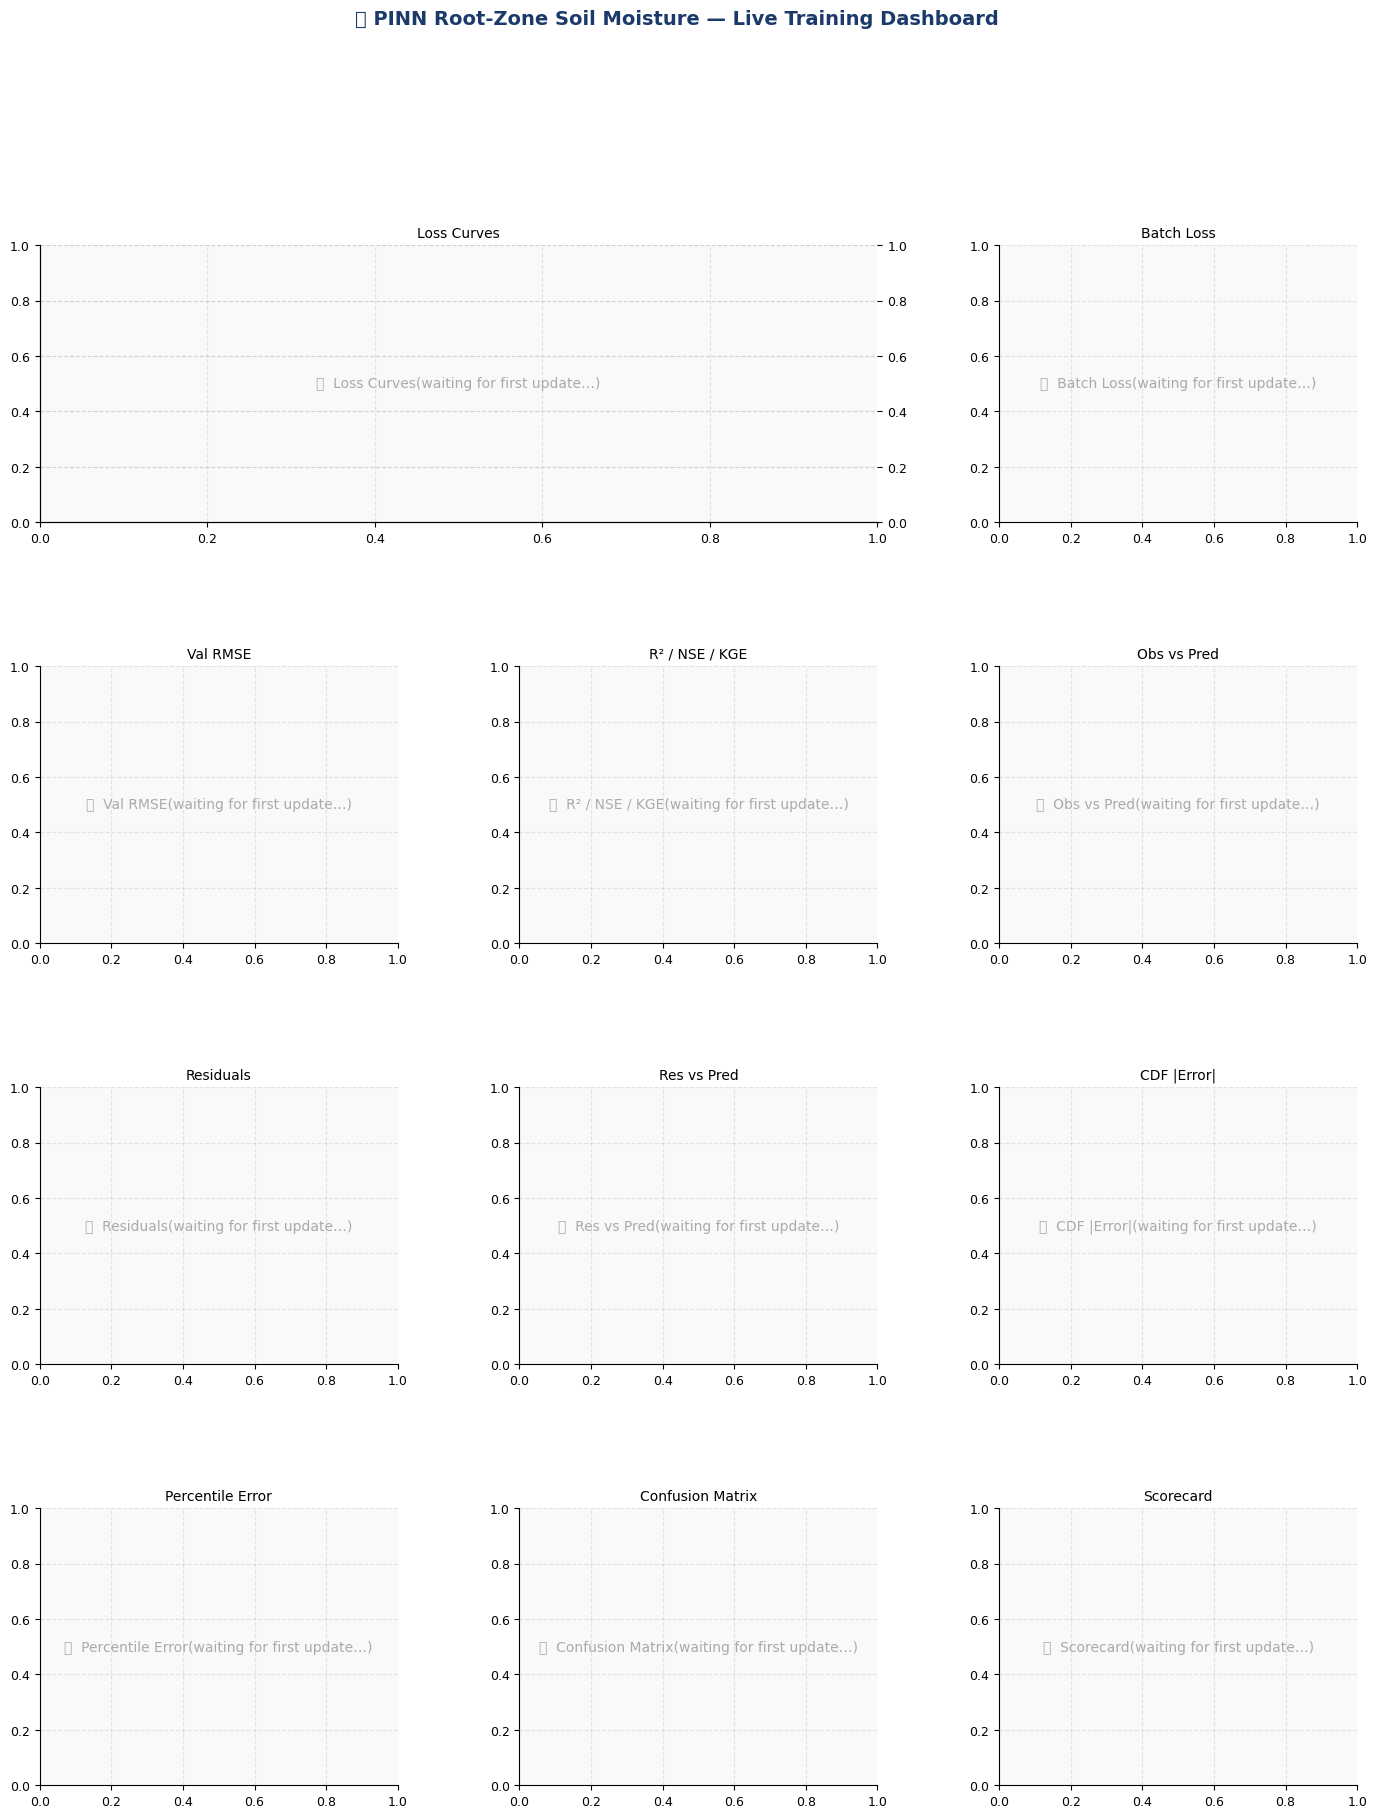

✓ Dashboard ready — start the Training cell ▼


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
#  Real-time dashboard
#  KEY DESIGN:
#   1. Figure is created and displayed HERE, ONCE, before training starts.
#   2. During training, only axis data is updated + fig.canvas.draw_idle() called.
#   3. No clear_output(), no plt.show() inside the loop → zero flicker.
#   4. ipywidgets (phase badge, metric boxes, status) update independently.
# ═══════════════════════════════════════════════════════════════════════════════

# ── History state ─────────────────────────────────────────────────────────────
H = dict(epoch=[], phase=[], lr_vals=[],
         loss_total=[], loss_data=[], loss_phys=[], loss_et=[], loss_bc=[],
         val_rmse=[], val_r2=[], val_nse=[], val_kge=[], val_ep=[],
         batch_idx=[], batch_loss=[])

# ── Metric helpers ────────────────────────────────────────────────────────────
def nse(y, p):
    return float(1 - np.sum((y-p)**2) / (np.sum((y-y.mean())**2) + EPS))

def kge(y, p):
    r = float(np.corrcoef(y, p)[0, 1])
    a = float(p.std() / (y.std() + EPS))
    b = float(p.mean() / (y.mean() + EPS))
    return 1 - math.sqrt((r-1)**2 + (a-1)**2 + (b-1)**2)

@torch.no_grad()
def validate(loader):
    model.eval()
    ps, ys = [], []
    for Xb, yb in loader:
        ps.append(model(Xb.to(DEVICE)).cpu().numpy())
        ys.append(yb.numpy())
    p = np.concatenate(ps).flatten(); y = np.concatenate(ys).flatten()
    return (float(np.sqrt(mean_squared_error(y, p))),
            float(r2_score(y, p)), nse(y, p), kge(y, p), y, p)

# ── ipywidgets ────────────────────────────────────────────────────────────────
BADGE_COLORS = {1:"#1B3A6B", 2:"#0D7680", 3:"#1A6B3C", 4:"#C45E00"}
BADGE_LABELS = {1:"Warmup (data only)", 2:"Intro Physics",
                3:"Full Adaptive PINN", 4:"Fine-tune"}

w_phase  = widgets.HTML(value="<i>not started</i>")
w_status = widgets.HTML(value="<i>Initialising…</i>")

METRIC_KEYS  = ["RMSE", "R²", "NSE", "KGE"]
METRIC_TGT   = {"RMSE":0.03, "R²":0.90, "NSE":0.90, "KGE":0.70}
METRIC_HIGHER= {"RMSE":False,"R²":True,"NSE":True,"KGE":True}
w_metrics = {k: widgets.HTML() for k in METRIC_KEYS}

def _badge(ph):
    c = BADGE_COLORS.get(ph,"#555"); l = BADGE_LABELS.get(ph,"")
    return (f'<span style="background:{c};color:#fff;padding:4px 12px;'
            f'border-radius:5px;font-weight:bold;font-size:13px">'
            f'Phase {ph} — {l}</span>')

def _metric_card(k, v):
    tgt = METRIC_TGT[k]; hb = METRIC_HIGHER[k]
    ok  = (v <= tgt) if not hb else (v >= tgt)
    bg  = "#d5f5e3" if ok else "#fdebd0"
    brd = "#1A6B3C" if ok else "#C45E00"
    return (f'<div style="border:2px solid {brd};border-radius:7px;background:{bg};'
            f'padding:7px 16px;text-align:center;min-width:115px;">'
            f'<div style="font-size:11px;color:#555">{k}</div>'
            f'<div style="font-size:22px;font-weight:bold">{v:.4f}</div>'
            f'<div style="font-size:10px">target {tgt} {"✓" if ok else "✗"}</div>'
            f'</div>')

def update_cards(rmse, r2, nse_, kge_):
    for k, v in zip(METRIC_KEYS, [rmse, r2, nse_, kge_]):
        w_metrics[k].value = _metric_card(k, v)

metric_row = widgets.HBox(list(w_metrics.values()),
                           layout=widgets.Layout(gap="10px", margin="6px 0"))

# ── Figure — created ONCE ─────────────────────────────────────────────────────
fig = plt.figure(figsize=(17, 20), facecolor="white")
fig.suptitle("🌱 PINN Root-Zone Soil Moisture — Live Training Dashboard",
             fontsize=14, fontweight="bold", color=NAVY, y=0.998)

gs = gridspec.GridSpec(4, 3, figure=fig, hspace=0.52, wspace=0.34)

# Row 0
ax_loss  = fig.add_subplot(gs[0, :2])
ax_lr    = ax_loss.twinx()
ax_batch = fig.add_subplot(gs[0, 2])
# Row 1
ax_rmse    = fig.add_subplot(gs[1, 0])
ax_r2nse   = fig.add_subplot(gs[1, 1])
ax_scatter = fig.add_subplot(gs[1, 2])
# Row 2
ax_res_hist = fig.add_subplot(gs[2, 0])
ax_res_pred = fig.add_subplot(gs[2, 1])
ax_cdf      = fig.add_subplot(gs[2, 2])
# Row 3
ax_pct  = fig.add_subplot(gs[3, 0])
ax_cm   = fig.add_subplot(gs[3, 1])
ax_sc   = fig.add_subplot(gs[3, 2])

ALL_AXES = [ax_loss, ax_batch, ax_rmse, ax_r2nse, ax_scatter,
            ax_res_hist, ax_res_pred, ax_cdf, ax_pct, ax_cm, ax_sc]

# Placeholder text in every panel so the figure looks nice before training
for ax, ttl in zip(ALL_AXES,
    ["Loss Curves","Batch Loss","Val RMSE","R² / NSE / KGE",
     "Obs vs Pred","Residuals","Res vs Pred","CDF |Error|",
     "Percentile Error","Confusion Matrix","Scorecard"]):
    ax.text(0.5, 0.5, f"⏳  {ttl}(waiting for first update…)",
            ha="center", va="center", transform=ax.transAxes,
            fontsize=10, color="#AAA")
    ax.set_title(ttl, fontsize=10)

plt.tight_layout(rect=[0, 0, 1, 0.998])

# ── Display widget stack + figure — BOTH displayed once ──────────────────────
display(widgets.VBox([w_phase, w_status, metric_row]))
plt.show()           # shows the figure in its own output area (ipympl)

print("✓ Dashboard ready — start the Training cell ▼")


## 🚀 Training
*Run this cell. The dashboard above updates every few batches — no pause, no flicker.*

In [11]:
# ── Optimiser & dynamic LR scheduler ─────────────────────────────────────────
optimizer = optim.Adam(model.parameters(), lr=CFG["lr"],
                       betas=(0.9, 0.999), weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="min",
    factor=CFG["lr_factor"],
    patience=CFG["lr_patience"],
    cooldown=CFG["lr_cooldown"],
    min_lr=CFG["lr_min"],
    threshold=CFG["lr_threshold"],
    threshold_mode="rel",
)

prev_ph = 0
best_rmse, best_state = float("inf"), None

# ── Phase-band colours ────────────────────────────────────────────────────────
PH_COL = {1:"#D6EAF8", 2:"#D5F5E3", 3:"#FDEBD0", 4:"#EBD9F7"}

# ── GPU monitoring ────────────────────────────────────────────────────────────
GPU_STATS = {"peak_mem": 0, "transfer_time": 0, "compute_time": 0}

# ═══════════════════════════════════════════════════════════════════════════════
#  REDRAW — updates axis contents then calls draw_idle() (non-blocking)
# ═══════════════════════════════════════════════════════════════════════════════
def redraw(val_y=None, val_p=None):
    ep = H["epoch"]; ve = H["val_ep"]

    for ax in ALL_AXES: ax.cla()
    ax_lr.cla()

    if ep:
        for key, col, ls, lw_ in [
            ("loss_total", NAVY,   "-",   2.0),
            ("loss_data",  TEAL,   "--",  1.3),
            ("loss_phys",  ORANGE, "--",  1.3),
            ("loss_et",    GREEN,  "--",  1.3),
            ("loss_bc",    PURPLE, ":",   1.0),
        ]:
            if H[key]:
                ax_loss.semilogy(ep, H[key], color=col, ls=ls, lw=lw_,
                                 label=key.replace("loss_", "L_"))
        if H["lr_vals"]:
            ax_lr.semilogy(ep[:len(H["lr_vals"])], H["lr_vals"], color=GOLD,
                           lw=0.9, ls="-.", alpha=0.7)
            ax_lr.set_ylabel("LR", color=GOLD, fontsize=8)
            ax_lr.tick_params(axis="y", labelcolor=GOLD, labelsize=7)
            ax_lr.spines["right"].set_visible(True)

        ph = H["phase"]
        prev_e, prev_p = ep[0], ph[0]
        for i in range(1, len(ep)):
            if ph[i] != prev_p or i == len(ep) - 1:
                ax_loss.axvspan(prev_e, ep[i], alpha=0.12,
                                color=PH_COL.get(prev_p, "#EEE"))
                prev_e, prev_p = ep[i], ph[i]
        ax_loss.set_xlabel("Epoch"); ax_loss.set_ylabel("Loss (log)")
        ax_loss.set_title("Training Loss Curves")
        ax_loss.legend(fontsize=7, ncol=5, loc="upper right")

    bl = H["batch_loss"][-80:]
    if bl:
        med = float(np.median(bl))
        colors_b = [RED if v > med * 2 else TEAL for v in bl]
        ax_batch.bar(range(len(bl)), bl, color=colors_b, width=1.0, alpha=0.85)
        ax_batch.axhline(float(np.mean(bl)), color=NAVY, lw=1.5, ls="--",
                         label=f"mean={np.mean(bl):.4f}")
        ax_batch.set_title("Batch Loss  (last 80)")
        ax_batch.set_xlabel("Batch (relative)"); ax_batch.set_ylabel("Loss")
        ax_batch.legend(fontsize=7)

    if H["val_rmse"]:
        ax_rmse.plot(ve, H["val_rmse"], color=NAVY, lw=2, label="RMSE")
        ax_rmse.axhline(0.03, color=RED, lw=1.4, ls="--", label="0.03 target")
        ax_rmse.fill_between(ve, H["val_rmse"], 0.03,
                             where=[v > 0.03 for v in H["val_rmse"]],
                             alpha=0.15, color=RED)
        ax_rmse.set_title("Validation RMSE"); ax_rmse.set_xlabel("Epoch")
        ax_rmse.set_ylabel("RMSE (m³/m³)"); ax_rmse.legend(fontsize=7)

    if H["val_r2"]:
        ax_r2nse.plot(ve[:len(H["val_r2"])], H["val_r2"],  color=TEAL,   lw=2,   label="R²")
        ax_r2nse.plot(ve[:len(H["val_nse"])], H["val_nse"], color=ORANGE, lw=2,   label="NSE")
        ax_r2nse.plot(ve[:len(H["val_kge"])], H["val_kge"], color=GREEN,  lw=1.4, ls="--", label="KGE")
        ax_r2nse.axhline(0.90, color=RED, lw=1.2, ls=":", alpha=0.6)
        ax_r2nse.set_title("R² / NSE / KGE"); ax_r2nse.set_xlabel("Epoch")
        ax_r2nse.legend(fontsize=7)

    if val_y is not None and val_p is not None:
        res = val_y - val_p
        abs_err = np.abs(res)

        h2d, xe, ye = np.histogram2d(val_y, val_p, bins=50)
        ax_scatter.imshow(np.log1p(h2d).T, origin="lower",
                          extent=[xe[0], xe[-1], ye[0], ye[-1]],
                          aspect="auto", cmap="YlOrRd", alpha=0.85)
        lo_ = min(val_y.min(), val_p.min()) - 0.005
        hi_ = max(val_y.max(), val_p.max()) + 0.005
        ax_scatter.plot([lo_, hi_], [lo_, hi_], NAVY, lw=1.8, ls="--", label="1:1")
        m_, b_ = np.polyfit(val_y, val_p, 1)
        xs_ = np.linspace(lo_, hi_, 80)
        ax_scatter.plot(xs_, m_ * xs_ + b_, ORANGE, lw=1.5, label=f"y={m_:.3f}x+{b_:.3f}")
        ax_scatter.text(0.97, 0.03,
                        f"RMSE={float(np.sqrt(mean_squared_error(val_y,val_p))):.4f}\n"
                        f"R²={float(r2_score(val_y,val_p)):.4f}\n"
                        f"r={float(pearsonr(val_y,val_p)[0]):.4f}",
                        transform=ax_scatter.transAxes, ha="right", va="bottom",
                        fontsize=8, family="monospace",
                        bbox=dict(boxstyle="round,pad=0.3", fc="white", ec=NAVY, alpha=0.9))
        ax_scatter.set_title("Obs vs Pred (Validation)")
        ax_scatter.set_xlabel("Observed θ"); ax_scatter.set_ylabel("Predicted θ")
        ax_scatter.legend(fontsize=7)

        bins_r = np.linspace(res.min(), res.max(), 50)
        ax_res_hist.hist(res, bins=bins_r, color=TEAL, edgecolor="white", lw=0.3, alpha=0.85)
        ax_res_hist.axvline(0, color=NAVY, lw=2, ls="--")
        ax_res_hist.axvline(res.mean(), color=ORANGE, lw=1.6, ls="-", label=f"μ={res.mean():.4f}")
        xs_r = np.linspace(res.min(), res.max(), 150)
        ax_res_hist.plot(xs_r,
                         sp_norm.pdf(xs_r, res.mean(), res.std()) * len(res) * (bins_r[1]-bins_r[0]),
                         color=PURPLE, lw=1.6, label="Gaussian fit")
        ax_res_hist.set_title("Residual Distribution")
        ax_res_hist.set_xlabel("Obs − Pred  (m³/m³)")
        ax_res_hist.legend(fontsize=7)

        hb_ = ax_res_pred.hexbin(val_p, res, gridsize=30, cmap="Blues", linewidths=0.1, mincnt=1)
        fig.colorbar(hb_, ax=ax_res_pred, fraction=0.04, pad=0.02, label="Count")
        ax_res_pred.axhline(0, color=NAVY, lw=1.5, ls="--")
        si = np.argsort(val_p)
        roll = pd.Series(res[si]).rolling(60, min_periods=1, center=True).mean()
        ax_res_pred.plot(val_p[si], roll, ORANGE, lw=1.8, label="Rolling mean")
        ax_res_pred.set_title("Residual vs Predicted")
        ax_res_pred.set_xlabel("Predicted θ"); ax_res_pred.set_ylabel("Residual")
        ax_res_pred.legend(fontsize=7)

        se_ = np.sort(abs_err)
        cdf_ = np.arange(1, len(se_)+1) / len(se_) * 100
        ax_cdf.plot(se_, cdf_, NAVY, lw=2)
        ax_cdf.axvline(0.03, color=RED, lw=1.5, ls="--", label="0.03 target")
        pct03 = (abs_err <= 0.03).mean() * 100
        ax_cdf.text(0.032, max(pct03 - 8, 5), f"{pct03:.1f}%", color=RED, fontsize=8)
        ax_cdf.set_xlim(0); ax_cdf.set_ylim(0, 103)
        ax_cdf.set_title("CDF of |Error|")
        ax_cdf.set_xlabel("|Error|  (m³/m³)"); ax_cdf.set_ylabel("Cumulative %")
        ax_cdf.legend(fontsize=7)

        pctls = np.arange(1, 100)
        qe_ = np.percentile(val_p, pctls) - np.percentile(val_y, pctls)
        ax_pct.fill_between(pctls, qe_, 0, where=qe_ >= 0, alpha=0.65, color=ORANGE, label="Over")
        ax_pct.fill_between(pctls, qe_, 0, where=qe_ < 0, alpha=0.65, color=TEAL,   label="Under")
        ax_pct.axhline(0, color=NAVY, lw=1.5, ls="--")
        ax_pct.set_title("Percentile Error Profile")
        ax_pct.set_xlabel("Percentile of Observed θ")
        ax_pct.set_ylabel("Pred − Obs  (m³/m³)")
        ax_pct.legend(fontsize=7)

        bins_c = np.array([0.0, 0.10, 0.20, 0.30, 0.40, 1.0])
        cls_lbl = ["<0.10", "0.10-0.20", "0.20-0.30", "0.30-0.40", "≥0.40"]
        yc = np.clip(np.digitize(val_y, bins_c, right=False) - 1, 0, 4)
        pc = np.clip(np.digitize(val_p, bins_c, right=False) - 1, 0, 4)
        cm_ = confusion_matrix(yc, pc, labels=range(5))
        rs = cm_.sum(1, keepdims=True)
        cm_n = np.divide(cm_, rs, out=np.zeros_like(cm_, dtype=float), where=rs != 0)
        im_ = ax_cm.imshow(cm_n, cmap="Blues", vmin=0, vmax=1)
        for ii in range(5):
            for jj in range(5):
                ax_cm.text(jj, ii, f"{cm_n[ii,jj]:.2f}", ha="center", va="center",
                           fontsize=7, color="white" if cm_n[ii,jj] > 0.5 else "black")
        ax_cm.set_xticks(range(5)); ax_cm.set_xticklabels(cls_lbl, rotation=30, ha="right", fontsize=7)
        ax_cm.set_yticks(range(5)); ax_cm.set_yticklabels(cls_lbl, fontsize=7)
        ax_cm.set_title("Confusion Matrix (row-norm)")
        ax_cm.set_xlabel("Pred class"); ax_cm.set_ylabel("Obs class")
        fig.colorbar(im_, ax=ax_cm, fraction=0.046, pad=0.04)

    if H["val_rmse"]:
        keys_ = ["RMSE", "R²", "NSE", "KGE"]
        tgts_ = [0.03, 0.90, 0.90, 0.70]
        hb_   = [False, True, True, True]
        cur_  = [H["val_rmse"][-1], H["val_r2"][-1], H["val_nse"][-1], H["val_kge"][-1]]
        cols_ = [GREEN if ((v <= t) if not h else (v >= t)) else RED for v, t, h in zip(cur_, tgts_, hb_)]
        bars_ = ax_sc.barh(keys_, cur_, color=cols_, alpha=0.85, edgecolor="white")
        for t_ in tgts_:
            ax_sc.axvline(t_, color=NAVY, lw=1.5, ls="--", alpha=0.5)
        for bar, v in zip(bars_, cur_):
            ax_sc.text(v + 0.003, bar.get_y() + bar.get_height() / 2, f"{v:.4f}", va="center", fontsize=8)
        ax_sc.set_xlim(0, 1.05)
        ax_sc.set_title("Live Scorecard  (green = met)")

    fig.canvas.draw_idle()
    fig.canvas.flush_events()

# ═══════════════════════════════════════════════════════════════════════════════
#  TRAINING LOOP — GPU OPTIMIZED
# ═══════════════════════════════════════════════════════════════════════════════
t0 = time.time()
_last_val_y = _last_val_p = None

epoch_bar = trange(CFG["total_epochs"], desc="Epochs",
                    bar_format="{l_bar}{bar:30}{r_bar}", colour="blue")

for epoch in epoch_bar:
    phase = get_phase(epoch)

    if phase != prev_ph:
        prev_ph = phase
        w_phase.value = _badge(phase)

    model.train()
    ep_tot = ep_d = ep_p = ep_et = ep_bc = 0.
    n_bat = len(tr_loader)

    batch_bar = tqdm(tr_loader, desc="  Batches", leave=False,
                     bar_format="{l_bar}{bar:20}{r_bar}", colour="cyan")

    for bidx, (Xb, yb) in enumerate(batch_bar):
        # ── Transfer to GPU (asynchronous if pin_memory=True) ──────────────────
        t_xfer_start = time.time()
        Xb, yb = Xb.to(DEVICE, non_blocking=True), yb.to(DEVICE, non_blocking=True)
   
        t_xfer = time.time() - t_xfer_start
        GPU_STATS["transfer_time"] += t_xfer

        # ── Forward + backward pass (all on GPU) ───────────────────────────────
        t_comp_start = time.time()
        optimizer.zero_grad()

        use_phys = phase in (2, 3)
        loss, comp = compute_loss(model, Xb, yb, phase, use_phys)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), CFG["grad_clip"])
        optimizer.step()
        
        t_comp = time.time() - t_comp_start
        GPU_STATS["compute_time"] += t_comp

        bl = float(loss.item())
        H["batch_loss"].append(bl)
        ep_tot += bl; ep_d += comp["data"]; ep_p += comp["phys"]
        ep_et  += comp["et"]; ep_bc += comp["bc"]
        
        # Track GPU memory
        if DEVICE == "cuda":
            curr_mem = torch.cuda.memory_allocated() / 1e9
            if curr_mem > GPU_STATS["peak_mem"]:
                GPU_STATS["peak_mem"] = curr_mem
        
        batch_bar.set_postfix(loss=f"{bl:.5f}", ph=phase)

        if bidx % CFG["log_every_batch"] == 0:
            redraw(_last_val_y, _last_val_p)

    nb_ = max(n_bat, 1)
    H["epoch"].append(epoch)
    H["phase"].append(phase)
    H["loss_total"].append(ep_tot / nb_)
    H["loss_data"].append(ep_d / nb_)
    H["loss_phys"].append(ep_p / nb_)
    H["loss_et"].append(ep_et / nb_)
    H["loss_bc"].append(ep_bc / nb_)

    if epoch % CFG["log_every_epoch"] == 0 or epoch == CFG["total_epochs"] - 1:
        rm_, r2_, ns_, kg_, val_y_, val_p_ = validate(vl_loader)
        _last_val_y, _last_val_p = val_y_, val_p_
        H["val_rmse"].append(rm_); H["val_r2"].append(r2_)
        H["val_nse"].append(ns_);  H["val_kge"].append(kg_)
        H["val_ep"].append(epoch)

        scheduler.step(rm_)

        if rm_ < best_rmse:
            best_rmse = rm_
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

        update_cards(rm_, r2_, ns_, kg_)
        current_lr = optimizer.param_groups[0]["lr"]
        H["lr_vals"].append(current_lr)
        elapsed = (time.time() - t0) / 60
        
        # ── GPU memory status ──────────────────────────────────────────────────
        gpu_mem_str = ""
        if DEVICE == "cuda":
            curr_mem = torch.cuda.memory_allocated() / 1e9
            gpu_mem_str = f" | GPU {curr_mem:.2f}GB (peak {GPU_STATS['peak_mem']:.2f}GB)"
        
        w_status.value = (
            f'<span style="font-family:monospace;font-size:12px">'
            f'Epoch {epoch:>5} | Ph{phase} | Loss {ep_tot/nb_:.5f} | '
            f'LR {current_lr:.2e} | RMSE <b>{rm_:.4f}</b> R² <b>{r2_:.4f}</b> '
            f'NSE <b>{ns_:.4f}</b> KGE <b>{kg_:.4f}</b> | '
            f'⏱ {elapsed:.1f} min | best {best_rmse:.4f}{gpu_mem_str}'
            f'</span>')
        epoch_bar.set_postfix(RMSE=f"{rm_:.4f}", R2=f"{r2_:.4f}", lr=f"{current_lr:.2e}", ph=phase)
        redraw(_last_val_y, _last_val_p)
    else:
        H["lr_vals"].append(optimizer.param_groups[0]["lr"])

# ── Final GPU stats ──────────────────────────────────────────────────────────
if DEVICE == "cuda":
    print(f"\n✓ GPU Performance Summary:")
    print(f"  Peak GPU Memory: {GPU_STATS['peak_mem']:.2f} GB")
    print(f"  Avg Transfer Time/Batch: {GPU_STATS['transfer_time'] / max(n_bat * CFG['total_epochs'], 1) * 1000:.2f} ms")
    print(f"  Avg Compute Time/Batch: {GPU_STATS['compute_time'] / max(n_bat * CFG['total_epochs'], 1) * 1000:.2f} ms")
    torch.cuda.empty_cache()

print(f"\n✓ Training complete!  Best val RMSE = {best_rmse:.5f} m³/m³")


Epochs:   0%|                              | 0/250 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1 [00:00<?, ?it/s]

...

  Batches:   0%|                    | 0/1 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1 [00:00<?, ?it/s]

  Batches:   0%|                    | 0/1 [00:00<?, ?it/s]


✓ GPU Performance Summary:
  Peak GPU Memory: 0.07 GB
  Avg Transfer Time/Batch: 0.13 ms
  Avg Compute Time/Batch: 168.21 ms

✓ Training complete!  Best val RMSE = 0.02685 m³/m³


## 📋 Final Evaluation & Static Report

In [16]:
if best_state:
    model.load_state_dict(best_state)
    print(f"✓ Restored best checkpoint  (val RMSE = {best_rmse:.5f})")

results = {}
for sname, loader_ in [("Validation", vl_loader), ("Test", te_loader)]:
    rm_, r2_, ns_, kg_, yt_, yp_ = validate(loader_)
    pr_  = float(pearsonr(yt_, yp_)[0])
    mae_ = float(mean_absolute_error(yt_, yp_))
    bi_  = (yp_.mean()-yt_.mean()) / (yt_.mean()+EPS) * 100
    ub_  = float(np.sqrt(np.mean(((yp_-yp_.mean())-(yt_-yt_.mean()))**2)))
    results[sname] = dict(RMSE=rm_,MAE=mae_,R2=r2_,NSE=ns_,
                           Pearson_r=pr_,KGE=kg_,Bias_pct=bi_,ubRMSE=ub_,
                           y_true=yt_,y_pred=yp_)

TGT_F  = dict(RMSE=0.03,R2=0.90,NSE=0.90,Pearson_r=0.94,KGE=0.70,Bias_pct=10.)
HIGHER_= dict(RMSE=False,MAE=False,R2=True,NSE=True,Pearson_r=True,
               KGE=True,Bias_pct=None,ubRMSE=False)

print("\n" + "═"*70)
print(f"  {'Metric':<14} {'Validation':>12} {'Test':>12} {'Target':>9}  ✓/✗")
print("─"*70)
for k in ["RMSE","MAE","ubRMSE","R2","NSE","Pearson_r","KGE","Bias_pct"]:
    vv = results["Validation"][k]; tv = results["Test"][k]
    tg = TGT_F.get(k, float("nan")); hb = HIGHER_[k]
    if math.isnan(tg):    st = ""
    elif hb is None:      st = "✓" if abs(vv)<=tg and abs(tv)<=tg else "✗"
    elif hb:              st = "✓" if vv>=tg and tv>=tg else "✗"
    else:                 st = "✓" if vv<=tg and tv<=tg else "✗"
    ts = f"{tg:.3f}" if not math.isnan(tg) else "  —  "
    print(f"  {k:<14} {vv:>12.4f} {tv:>12.4f} {ts:>9}  {st}")
print("═"*70)


✓ Restored best checkpoint  (val RMSE = 0.02685)

══════════════════════════════════════════════════════════════════════
  Metric           Validation         Test    Target  ✓/✗
──────────────────────────────────────────────────────────────────────
  RMSE                 0.0268       0.0277     0.030  ✓
  MAE                  0.0208       0.0207       —    
  ubRMSE               0.0240       0.0248       —    
  R2                   0.9351       0.9321     0.900  ✓
  NSE                  0.9351       0.9321     0.900  ✓
  Pearson_r            0.9759       0.9753     0.940  ✓
  KGE                  0.9028       0.8930     0.700  ✓
  Bias_pct            -3.2964      -3.3988    10.000  ✓
══════════════════════════════════════════════════════════════════════


TP - True Positive
FP - False Positive
TN - True Negative
FN - False Negative
TP=629, FP=7, TN=38, FN=13
Accuracy=0.971 | Precision=0.989 | Recall=0.980 | F1=0.984


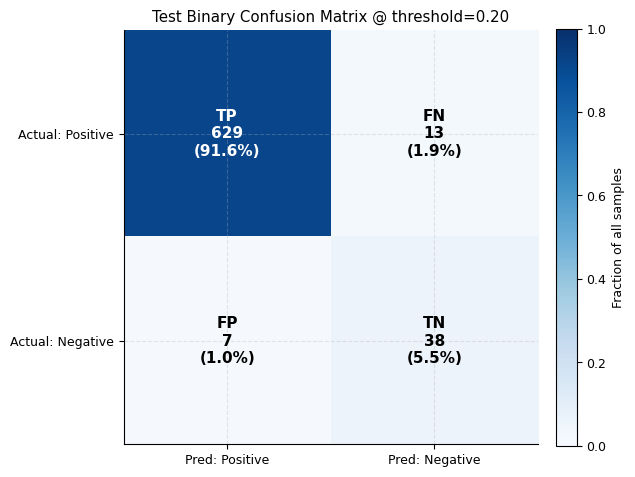

In [24]:
# Binary confusion matrix with TP / FP / TN / FN
# Run this after the "Final Evaluation & Static Report" cell.

split_name = "Test"   # Change to "Validation" if needed
threshold = 0.20      # Moisture threshold to convert regression to binary

if "results" not in globals() or split_name not in results:
    raise RuntimeError("Run the Final Evaluation cell first so `results` is available.")

y_true = results[split_name]["y_true"]
y_pred = results[split_name]["y_pred"]

true_pos = y_true >= threshold
pred_pos = y_pred >= threshold

# Confusion terms
TP = int(np.sum(true_pos & pred_pos))
FP = int(np.sum(~true_pos & pred_pos))
TN = int(np.sum(~true_pos & ~pred_pos))
FN = int(np.sum(true_pos & ~pred_pos))

# Matrix layout:
# rows = actual (Positive, Negative)
# cols = predicted (Positive, Negative)
cm_terms = np.array([[TP, FN], [FP, TN]], dtype=np.int64)
cm_norm = cm_terms / max(cm_terms.sum(), 1)

fig_cm, ax_cm = plt.subplots(figsize=(6, 5), facecolor="white")
im = ax_cm.imshow(cm_norm, cmap="Blues", vmin=0.0, vmax=1.0)

labels = np.array([["TP", "FN"], ["FP", "TN"]])
for i in range(2):
    for j in range(2):
        txt_color = "white" if cm_norm[i, j] > 0.5 else "black"
        ax_cm.text(
            j,
            i,
            f"{labels[i, j]}\n{cm_terms[i, j]}\n({cm_norm[i, j]*100:.1f}%)",
            ha="center",
            va="center",
            fontsize=11,
            color=txt_color,
            fontweight="bold",
        )

ax_cm.set_xticks([0, 1])
ax_cm.set_xticklabels(["Pred: Positive", "Pred: Negative"])
ax_cm.set_yticks([0, 1])
ax_cm.set_yticklabels(["Actual: Positive", "Actual: Negative"])
ax_cm.set_title(f"{split_name} Binary Confusion Matrix @ threshold={threshold:.2f}")

cbar = fig_cm.colorbar(im, ax=ax_cm, fraction=0.046, pad=0.04)
cbar.set_label("Fraction of all samples")

accuracy = (TP + TN) / max(cm_terms.sum(), 1)
precision = TP / max(TP + FP, 1)
recall = TP / max(TP + FN, 1)
f1 = 2 * precision * recall / max(precision + recall, 1e-12)

print("TP - True Positive")
print("FP - False Positive")
print("TN - True Negative")
print("FN - False Negative")
print(f"TP={TP}, FP={FP}, TN={TN}, FN={FN}")
print(f"Accuracy={accuracy:.3f} | Precision={precision:.3f} | Recall={recall:.3f} | F1={f1:.3f}")

plt.tight_layout()
plt.show()

## 🔲 Standalone Confusion Matrix

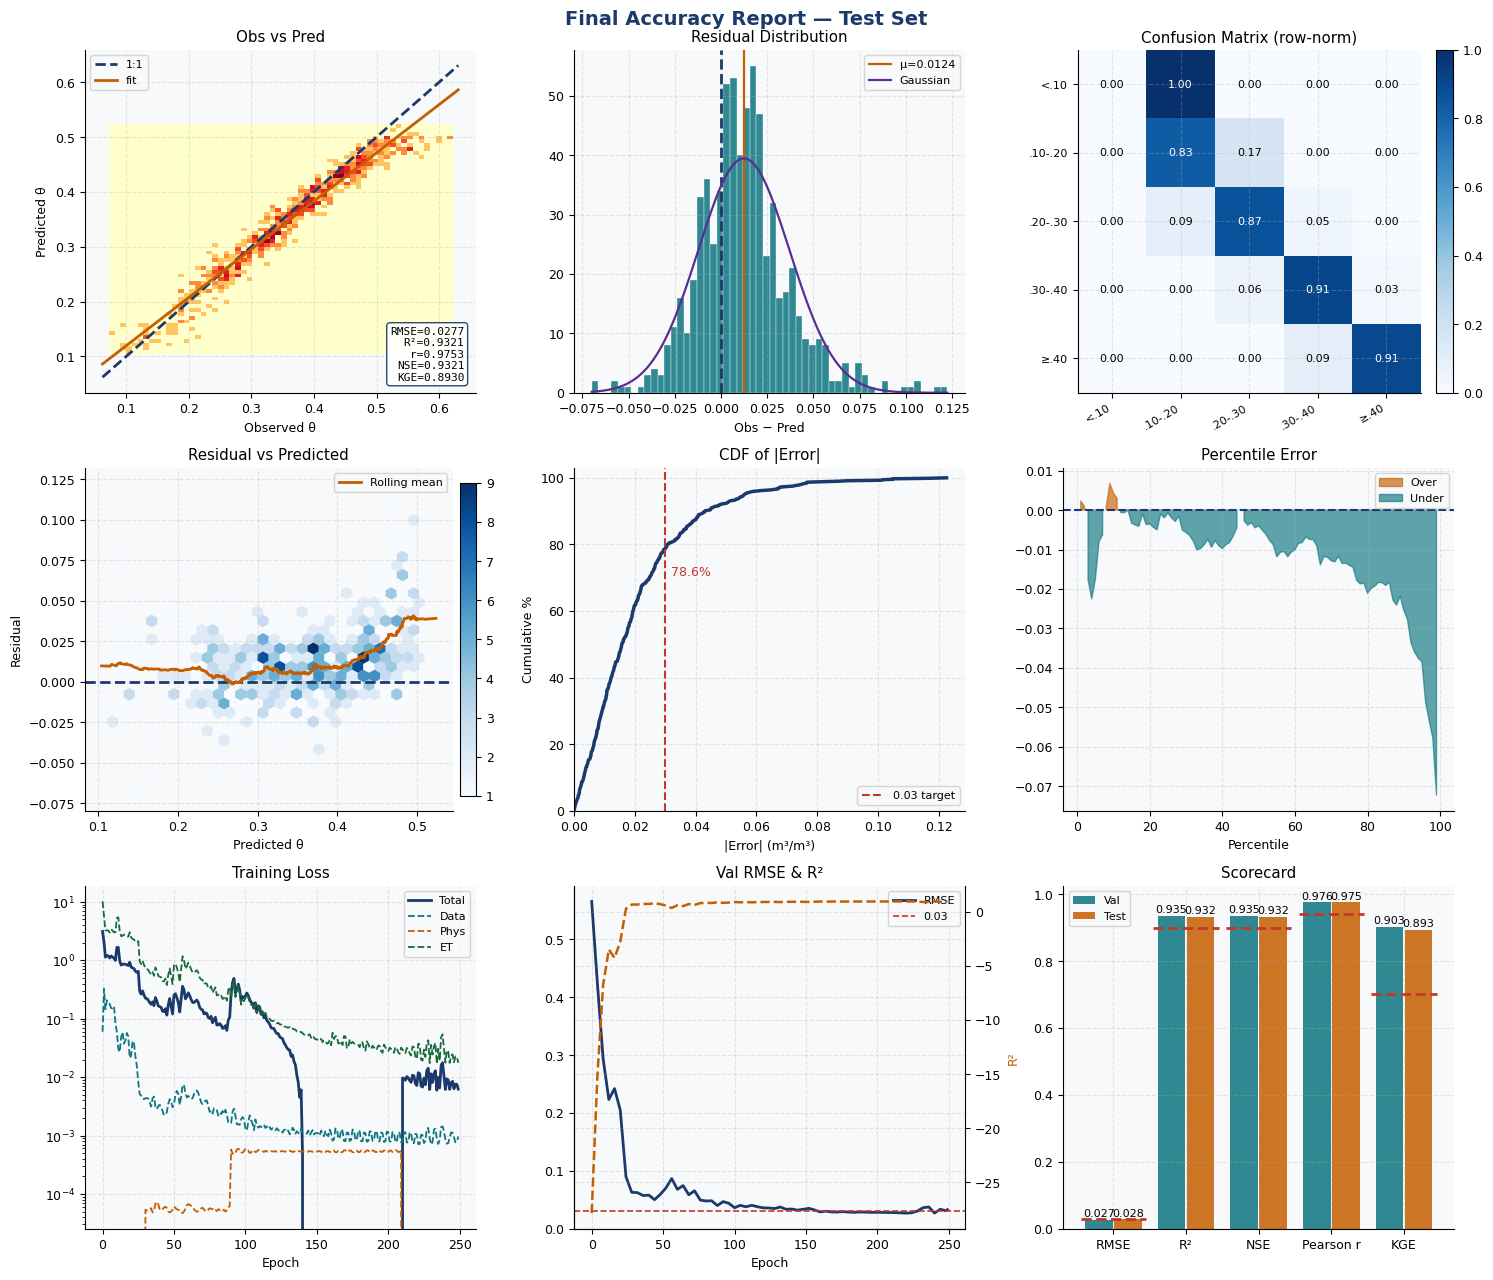

✓ Saved pinn_final_accuracy_report.png


In [25]:
# ── Final static 9-panel figure (saved to disk) ───────────────────────────────
plt.ioff()
yt = results["Test"]["y_true"]; yp = results["Test"]["y_pred"]
mv = results["Validation"];     mt = results["Test"]
res= yt - yp; ae = np.abs(res)

fig2, ax2 = plt.subplots(3, 3, figsize=(15, 13), facecolor="white")
fig2.suptitle("Final Accuracy Report — Test Set", fontsize=14,
              fontweight="bold", color=NAVY)

# 1 Scatter
a = ax2[0,0]
h2, xe, ye = np.histogram2d(yt, yp, bins=60)
a.imshow(np.log1p(h2).T, origin="lower",
         extent=[xe[0],xe[-1],ye[0],ye[-1]], aspect="auto", cmap="YlOrRd")
lo_,hi_ = min(yt.min(),yp.min())-.01, max(yt.max(),yp.max())+.01
a.plot([lo_,hi_],[lo_,hi_], NAVY, lw=2, ls="--", label="1:1")
m_,b_=np.polyfit(yt,yp,1); xs_=np.linspace(lo_,hi_,80)
a.plot(xs_,m_*xs_+b_,ORANGE,lw=2,label="fit")
a.text(.97,.03,
    f"RMSE={mt['RMSE']:.4f}\nR²={mt['R2']:.4f}\n"
    f"r={mt['Pearson_r']:.4f}\nNSE={mt['NSE']:.4f}\nKGE={mt['KGE']:.4f}",
    transform=a.transAxes,ha="right",va="bottom",fontsize=8,family="monospace",
    bbox=dict(boxstyle="round,pad=0.3",fc="white",ec=NAVY,alpha=0.92))
a.set_title("Obs vs Pred"); a.set_xlabel("Observed θ"); a.set_ylabel("Predicted θ")
a.legend(fontsize=8)

# 2 Residual hist
a = ax2[0,1]
b_ = np.linspace(res.min(),res.max(),55)
a.hist(res,bins=b_,color=TEAL,edgecolor="white",lw=0.3,alpha=0.85)
a.axvline(0,color=NAVY,lw=2,ls="--")
a.axvline(res.mean(),color=ORANGE,lw=1.6,ls="-",label=f"μ={res.mean():.4f}")
xs_r=np.linspace(res.min(),res.max(),150)
a.plot(xs_r,sp_norm.pdf(xs_r,res.mean(),res.std())*len(res)*(b_[1]-b_[0]),
       PURPLE,lw=1.6,label="Gaussian")
a.set_title("Residual Distribution"); a.set_xlabel("Obs − Pred"); a.legend(fontsize=8)

# 3 Confusion matrix
a = ax2[0,2]
bc2=np.array([0,.10,.20,.30,.40,1.]); lbl2=["<.10",".10-.20",".20-.30",".30-.40","≥.40"]
yc=np.clip(np.digitize(yt,bc2,right=False)-1,0,4)
pc=np.clip(np.digitize(yp,bc2,right=False)-1,0,4)
cm_=confusion_matrix(yc,pc,labels=range(5))
rs_=cm_.sum(1,keepdims=True)
cmn=np.divide(cm_,rs_,out=np.zeros_like(cm_,dtype=float),where=rs_!=0)
im2=a.imshow(cmn,cmap="Blues",vmin=0,vmax=1)
for ii in range(5):
    for jj in range(5):
        a.text(jj,ii,f"{cmn[ii,jj]:.2f}",ha="center",va="center",fontsize=8,
               color="white" if cmn[ii,jj]>0.5 else "black")
a.set_xticks(range(5)); a.set_xticklabels(lbl2,rotation=30,ha="right",fontsize=8)
a.set_yticks(range(5)); a.set_yticklabels(lbl2,fontsize=8)
a.set_title("Confusion Matrix (row-norm)")
fig2.colorbar(im2,ax=a,fraction=0.046,pad=0.04)

# 4 Residual vs predicted
a = ax2[1,0]
hb2=a.hexbin(yp,res,gridsize=30,cmap="Blues",linewidths=0.1,mincnt=1)
fig2.colorbar(hb2,ax=a,fraction=0.04,pad=0.02)
a.axhline(0,color=NAVY,lw=2,ls="--")
si=np.argsort(yp); rl=pd.Series(res[si]).rolling(80,min_periods=1,center=True).mean()
a.plot(yp[si],rl,ORANGE,lw=2,label="Rolling mean")
a.set_title("Residual vs Predicted"); a.set_xlabel("Predicted θ")
a.set_ylabel("Residual"); a.legend(fontsize=8)

# 5 CDF
a = ax2[1,1]
se3=np.sort(ae); cdf3=np.arange(1,len(se3)+1)/len(se3)*100
a.plot(se3,cdf3,NAVY,lw=2.5)
a.axvline(0.03,color=RED,lw=1.5,ls="--",label="0.03 target")
p03=(ae<=0.03).mean()*100
a.text(0.032,max(p03-8,5),f"{p03:.1f}%",color=RED,fontsize=9)
a.set_xlim(0); a.set_ylim(0,103)
a.set_title("CDF of |Error|"); a.set_xlabel("|Error| (m³/m³)")
a.set_ylabel("Cumulative %"); a.legend(fontsize=8)

# 6 Percentile error
a = ax2[1,2]
pct3=np.arange(1,100)
qe3=np.percentile(yp,pct3)-np.percentile(yt,pct3)
a.fill_between(pct3,qe3,0,where=qe3>=0,alpha=0.65,color=ORANGE,label="Over")
a.fill_between(pct3,qe3,0,where=qe3< 0,alpha=0.65,color=TEAL,  label="Under")
a.axhline(0,color=NAVY,lw=1.5,ls="--")
a.set_title("Percentile Error"); a.set_xlabel("Percentile"); a.legend(fontsize=8)

# 7 Loss history
a = ax2[2,0]
if H["epoch"]:
    a.semilogy(H["epoch"],H["loss_total"],NAVY,  lw=2,   label="Total")
    a.semilogy(H["epoch"],H["loss_data"], TEAL,  lw=1.3, ls="--", label="Data")
    a.semilogy(H["epoch"],H["loss_phys"], ORANGE,lw=1.3, ls="--", label="Phys")
    a.semilogy(H["epoch"],H["loss_et"],   GREEN, lw=1.3, ls="--", label="ET")
a.set_title("Training Loss"); a.set_xlabel("Epoch"); a.legend(fontsize=8)

# 8 Val RMSE + R²
a = ax2[2,1]
if H["val_rmse"]:
    ve3 = H["val_ep"][:len(H["val_rmse"])]
    a.plot(ve3,H["val_rmse"],NAVY,lw=2,label="RMSE")
    ax2b=a.twinx()
    ax2b.plot(H["val_ep"][:len(H["val_r2"])],H["val_r2"],ORANGE,lw=1.8,ls="--",label="R²")
    ax2b.set_ylabel("R²",color=ORANGE); ax2b.spines["right"].set_visible(True)
a.axhline(0.03,color=RED,lw=1.2,ls="--",label="0.03")
a.set_title("Val RMSE & R²"); a.set_xlabel("Epoch"); a.legend(fontsize=8)

# 9 Scorecard
a = ax2[2,2]
ks4=["RMSE","R²","NSE","Pearson r","KGE"]
ts4=[0.03,0.90,0.90,0.94,0.70]
vc4=[mv["RMSE"],mv["R2"],mv["NSE"],mv["Pearson_r"],mv["KGE"]]
tc4=[mt["RMSE"],mt["R2"],mt["NSE"],mt["Pearson_r"],mt["KGE"]]
xb4=np.arange(len(ks4))
bv4=a.bar(xb4-.2,vc4,.38,color=TEAL,  alpha=.85,label="Val")
bt4=a.bar(xb4+.2,tc4,.38,color=ORANGE,alpha=.85,label="Test")
for i,t_ in enumerate(ts4): a.hlines(t_,xb4[i]-.45,xb4[i]+.45,colors=RED,lw=2,ls="--")
for bar in [*bv4,*bt4]:
    a.text(bar.get_x()+bar.get_width()/2,bar.get_height()+.003,
           f"{bar.get_height():.3f}",ha="center",va="bottom",fontsize=8)
a.set_xticks(xb4); a.set_xticklabels(ks4,fontsize=9)
a.set_title("Scorecard"); a.legend(fontsize=8)

plt.tight_layout()
plt.savefig("pinn_final_accuracy_report.png", dpi=160, bbox_inches="tight")
plt.show()
plt.ion()
print("✓ Saved pinn_final_accuracy_report.png")


## 💾 Save Artefacts

In [26]:
os.makedirs("checkpoints", exist_ok=True)
os.makedirs("results",     exist_ok=True)

torch.save({"model_state": best_state or model.state_dict(),
            "val_rmse": best_rmse, "cfg": CFG},
           "checkpoints/pinn_best.pt")
print("✓ checkpoints/pinn_best.pt")

pd.DataFrame({k: H[k] for k in
    ["epoch","phase","loss_total","loss_data","loss_phys","loss_et","loss_bc"]
}).to_csv("results/training_history.csv", index=False)

for sn, res_ in results.items():
    pd.DataFrame({"y_true": res_["y_true"], "y_pred": res_["y_pred"],
                  "residual": res_["y_true"]-res_["y_pred"]}
    ).to_csv(f"results/{sn.lower()}_predictions.csv", index=False)
    print(f"✓ results/{sn.lower()}_predictions.csv")

with open("results/config.json","w") as f:
    json.dump({k:v for k,v in CFG.items() if not callable(v)}, f, indent=2)
print("✓ results/config.json")


✓ checkpoints/pinn_best.pt
✓ results/validation_predictions.csv
✓ results/test_predictions.csv
✓ results/config.json


## 🔭 Single-Row Inference

In [27]:
@torch.no_grad()
def predict(row_dict):
    x = np.zeros((1, len(FEATURE_NAMES)), dtype=np.float32)
    for col, val in row_dict.items():
        if col in IDX: x[0, IDX[col]] = float(val)
    xs = scaler.transform(x).astype(np.float32)
    for col in PHYS_COLS:
        if col in row_dict: xs[0, IDX[col]] = float(row_dict[col])
    model.eval()
    return round(float(model(torch.tensor(xs).to(DEVICE)).item()), 5)

sample = df_clean.iloc[te_idx[0]]
sd     = {c: sample[c] for c in FEATURE_NAMES if c in sample}
pred   = predict(sd)
true_  = sample[TARGET] if TARGET in sample else "N/A"
print(f"  True θ  : {true_}")
print(f"  Pred θ  : {pred}  m³/m³")
print(f"  |Error| : {abs(float(true_)-pred):.5f}  m³/m³")


  True θ  : 0.3114
  Pred θ  : 0.31785  m³/m³
  |Error| : 0.00645  m³/m³
